# 09 - Tính chất vật lý "rẻ" suy từ tensor Q (dataset A4)

**Bối cảnh:** pipeline chỉ giải 1 bài toán vật lý (đồng nhất hóa đàn hồi 2D plane-stress, PBC) cho ra Q (3×3). Mọi tính chất là hàm đại số của Q đều "miễn phí": không cần solver mới, gradient giải tích có sẵn qua `dS = -S·dQ·S` (`pipeline/phase5_cvae/real_physics.py::solve_elastic_with_grad`).

**Dữ liệu:** `outputs/phase3_a4/{val,test}_props.npz` do `analysis/scripts/backfill_elastic_props_npz.py` sinh ra: FE lại trên ảnh 64×64 → lưới 50×50, dùng penal và ν0 thật của từng mẫu. Chỉ dùng **val + test** vì train bị augment ×6 (xoay/lật): các bản sao gần trùng nhau sẽ rò rỉ giữa các fold cross-validation và làm phồng R² ở mục 3. Loại các mẫu có |ν12 gốc − ν12 tính lại| > 0.1 (nhiễu resize, cùng quy ước QC với backfill f1/f2).

**Câu hỏi cần trả lời:**
1. Các giá trị có tôn trọng cận vật lý không (Voigt, Hashin–Shtrikman)? Đây là kiểm tra tính đúng của FE.
2. Tính chất nào **mang thông tin mới** so với 5 điều kiện hiện có (v12, v21, volfrac, void_size_frac, ν0)? Tính chất dư thừa thì thêm vào condition không giúp gì.
3. Proxy chống ấn lõm: auxetic có thật sự cứng hơn khi cố định mật độ không?
4. Đánh đổi ν ↔ độ cứng riêng: biên Pareto trông ra sao?

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score

from utils import REPO_ROOT

sys.path.insert(0, str(REPO_ROOT))
from analysis.pareto.frontier import is_pareto_efficient  # noqa: E402

A4_DIR = REPO_ROOT / "outputs" / "phase3_a4"
CONDITIONS = ["v12", "v21", "volfrac", "void_size_frac", "nu0"]
PROPS = ["E_x", "E_y", "G_xy", "B_eff", "M_x", "M_y",
         "c_qL_x", "c_qL_y", "c_qT_x"]


def load_split(split: str) -> pd.DataFrame:
    """Ghép {split}.npz (điều kiện gốc) với {split}_props.npz (tính chất
    backfill) theo chỉ số hàng - 2 file cùng thứ tự do backfill ghi theo i."""
    d = np.load(A4_DIR / f"{split}.npz", allow_pickle=True)
    p = np.load(A4_DIR / f"{split}_props.npz")
    df = pd.DataFrame({
        "v12": d["v12"], "v21": d["v21"],
        "volfrac": d["volfrac_achieved"],
        "void_size_frac": d["params"][:, 4],
        "nu0": d["nu"], "seed": d["seed_names"],
    })
    for k in p["keys"]:
        df[str(k)] = p[k]
    df["split"] = split
    return df


raw = pd.concat([load_split("val"), load_split("test")], ignore_index=True)
raw["dv12"] = (raw.v12 - raw.v12_recheck).abs()
df = raw[(raw.dv12 <= 0.1) & raw.E_x.notna()].reset_index(drop=True)
print(f"n={len(raw)} -> sau QC n={len(df)} "
      f"(loại {len(raw) - len(df)} mẫu nhiễu resize/FE lỗi)")
df[PROPS + ["rel_density"]].describe(percentiles=[.01, .5, .99]).round(4)

n=4878 -> sau QC n=4778 (loại 100 mẫu nhiễu resize/FE lỗi)


,E_x,E_y,G_xy,B_eff,M_x,M_y,c_qL_x,c_qL_y,c_qT_x,rel_density
count,4778.0000,4778.0000,4778.0000,4778.0000,4778.0000,4778.0000,4778.0000,4778.0000,4778.0000,4778.0000
mean,0.0995,0.1080,0.0093,0.0349,0.1298,0.1366,0.4952,0.5073,0.1277,0.5219
std,0.0345,0.0561,0.0053,0.0155,0.0354,0.0502,0.0689,0.0773,0.0296,0.0822
min,0.0064,0.0074,0.0003,0.0029,0.0067,0.0080,0.1113,0.1568,0.0237,0.2996
1%,0.0173,0.0342,0.0014,0.0099,0.0187,0.0625,0.1848,0.3913,0.0543,0.3114
50%,0.0982,0.0900,0.0085,0.0320,0.1313,0.1237,0.5094,0.4926,0.1288,0.5353
99%,0.1828,0.3284,0.0277,0.0820,0.1923,0.3462,0.5882,0.7840,0.2077,0.6741
max,0.2964,0.3611,0.0387,0.1030,0.3038,0.3749,0.7358,0.8212,0.2478,0.6990


## 1. Kiểm tra cận vật lý

Tất cả mô-đun đã chuẩn hóa theo E0, ρ = mật độ tương đối.
- **Voigt:** Q ≤ ρ·Q_solid, suy ra M_x = Q11/E0 ≤ ρ/(1−ν0²). Với SIMP penal ≥ 1 thì x^p ≤ x, nên cận này phải đúng tuyệt đối.
- **Hashin–Shtrikman 2D** (pha rỗng + nền κs = 1/(2(1−ν0)), μs = 1/(2(1+ν0))): B_HS = κs·ρ·μs / ((1−ρ)κs + μs). B_eff/B_HS ≤ 1 bắt buộc; tỉ số này cũng là **hiệu suất độ cứng khối** (1 = tối ưu lý thuyết).

In [2]:
ks = 1 / (2 * (1 - df.nu0))
ms = 1 / (2 * (1 + df.nu0))
rho = df.rel_density
df["B_HS"] = ks * rho * ms / ((1 - rho) * ks + ms)
df["B_eff_over_HS"] = df.B_eff / df.B_HS
voigt_Mx = rho / (1 - df.nu0**2)
voigt_My = voigt_Mx

tol = 1e-6
print(f"Vi phạm Voigt M_x: {(df.M_x > voigt_Mx + tol).mean():.3%}, "
      f"M_y: {(df.M_y > voigt_My + tol).mean():.3%}")
print(f"Vi phạm HS bulk (B_eff/B_HS > 1): "
      f"{(df.B_eff_over_HS > 1 + tol).mean():.3%}")
print("B_eff/B_HS percentiles [1,25,50,75,99]:",
      np.percentile(df.B_eff_over_HS, [1, 25, 50, 75, 99]).round(3))

Vi phạm Voigt M_x: 0.000%, M_y: 0.000%
Vi phạm HS bulk (B_eff/B_HS > 1): 0.000%
B_eff/B_HS percentiles [1,25,50,75,99]: [0.063 0.127 0.168 0.214 0.406]


## 2. Tương quan Spearman giữa điều kiện hiện có và tính chất mới

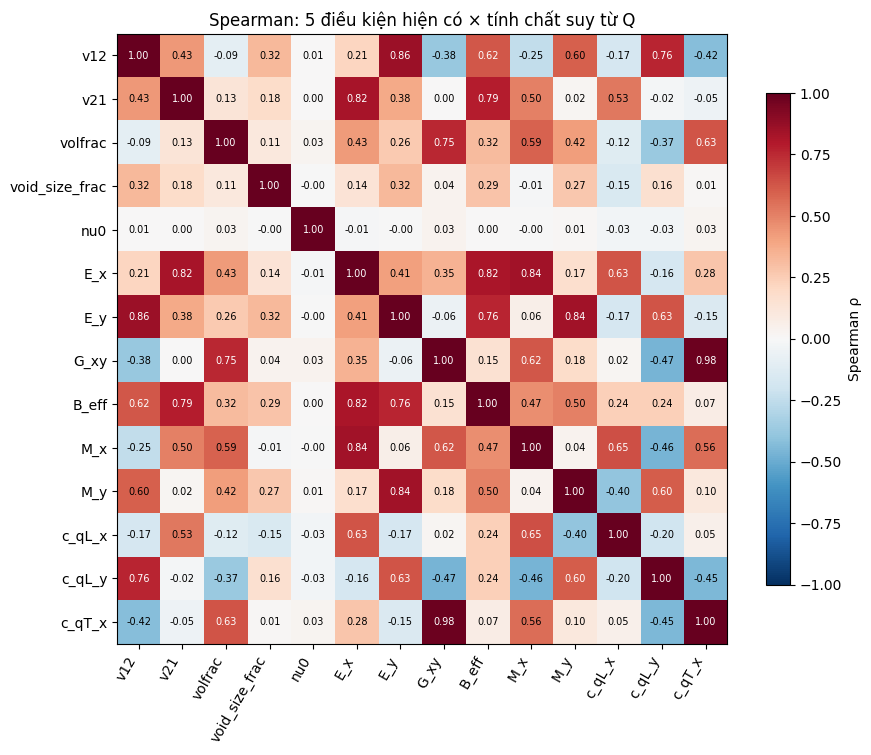

In [3]:
cols = CONDITIONS + PROPS
corr = df[cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols)), cols, rotation=60, ha="right")
ax.set_yticks(range(len(cols)), cols)
for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center",
                fontsize=7,
                color="white" if abs(corr.values[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman ρ")
ax.set_title("Spearman: 5 điều kiện hiện có × tính chất suy từ Q")
fig.tight_layout()
plt.show()

## 3. Tính chất nào mang thông tin MỚI?

Với mỗi tính chất, đo R² (5-fold CV, gradient boosting) khi dự đoán nó **từ 5 điều kiện hiện có**. R² ≈ 1 nghĩa là tính chất đã bị các điều kiện hiện có quyết định: thêm vào condition vector không thêm bậc tự do nào, và cVAE cũng không điều khiển nó độc lập được. R² thấp nghĩa là tính chất mang thông tin hình học mới, đáng để làm condition hoặc mục tiêu refinement. Cột `R2_rho_only` cho biết riêng mật độ đã giải thích bao nhiêu.

In [4]:
cv = KFold(n_splits=5, shuffle=True, random_state=0)


def cv_r2(features, target):
    """R² trung bình 5-fold của HistGradientBoosting dự đoán target."""
    model = HistGradientBoostingRegressor(max_iter=300, random_state=0)
    return cross_val_score(model, df[features], df[target], cv=cv,
                           scoring="r2").mean()


rows = []
for p in PROPS:
    rows.append({
        "property": p,
        "R2_from_5_conditions": cv_r2(CONDITIONS, p),
        "R2_rho_only": cv_r2(["rel_density"], p),
    })
info = pd.DataFrame(rows).set_index("property")
info["new_info (1-R2)"] = 1 - info.R2_from_5_conditions
info.sort_values("R2_from_5_conditions").round(3)

,R2_from_5_conditions,R2_rho_only,new_info (1-R2)
property,,,
c_qT_x,0.804,0.410,0.196
G_xy,0.843,0.609,0.157
M_x,0.918,0.336,0.082
c_qL_x,0.924,0.122,0.076
E_x,0.927,0.177,0.073
B_eff,0.937,0.092,0.063
c_qL_y,0.939,0.148,0.061
M_y,0.955,0.211,0.045
E_y,0.967,0.156,0.033


## 4. Proxy chống ấn lõm: auxetic có cứng hơn khi cố định mật độ?

Proxy Hertz kinh điển H ∝ [E/(1−ν²)]^γ. Trong plane stress đẳng hướng, E/(1−ν²) **chính là Q11**, nên proxy tự nhiên cho ấn lõm theo trục y là M_y = Q22/E0 (mô-đun khi bị ràng buộc ngang). Luận điểm "auxetic chống ấn lõm tốt hơn" giả định E giữ nguyên khi ν giảm. Ở đây kiểm tra điều đó bằng dữ liệu thật: trong từng nhóm mật độ, M_y/ρ có tăng khi ν21 âm hơn không? Spearman âm nghĩa là auxetic hơn thì cứng hơn.

In [5]:
df["rho_bin"] = pd.qcut(df.rel_density, 5)
tab = []
for b, g in df.groupby("rho_bin", observed=True):
    r_y, p_y = spearmanr(g.v21, g.M_y / g.rel_density)
    r_x, p_x = spearmanr(g.v12, g.M_x / g.rel_density)
    tab.append({"rho_bin": str(b), "n": len(g),
                "spearman(v21, M_y/ρ)": r_y, "p_y": p_y,
                "spearman(v12, M_x/ρ)": r_x, "p_x": p_x})
pd.DataFrame(tab).round(4)

,rho_bin,n,"spearman(v21, M_y/ρ)",p_y,"spearman(v12, M_x/ρ)",p_x
0,"(0.299, 0.462]",956,0.5417,0.0000,0.2759,0.0
1,"(0.462, 0.519]",955,0.3535,0.0000,-0.1804,0.0
2,"(0.519, 0.55]",957,-0.1744,0.0000,-0.3154,0.0
3,"(0.55, 0.585]",954,-0.2063,0.0000,-0.2989,0.0
4,"(0.585, 0.699]",956,0.1288,0.0001,0.1479,0.0


## 5. Đánh đổi ν12 ↔ độ cứng riêng E_x/ρ

Mục tiêu kép: ν12 càng âm càng tốt (minimize), E_x/ρ càng lớn càng tốt (maximize → minimize −E_x/ρ). Biên Pareto dùng lại `analysis/pareto/frontier.py::is_pareto_efficient`.

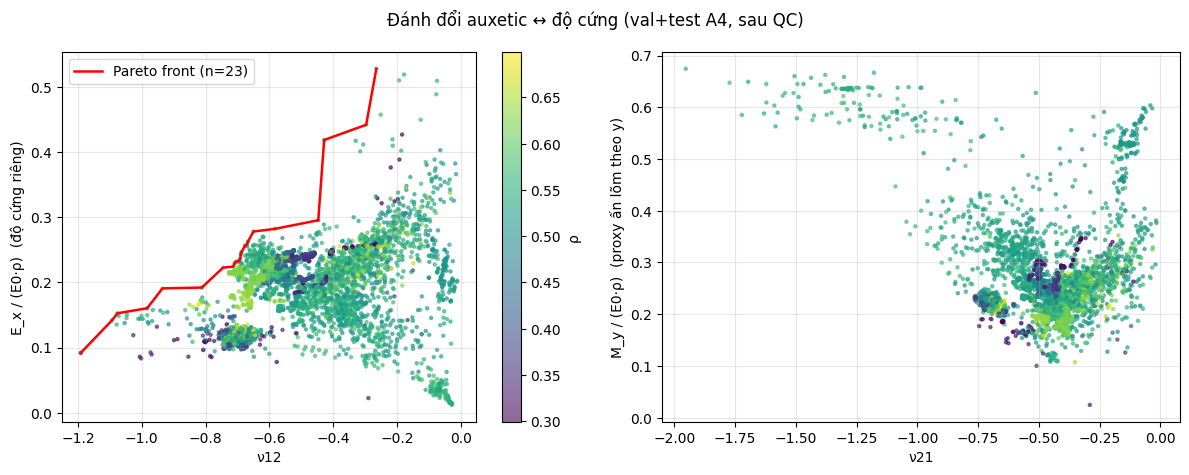

Mẫu trên biên Pareto (ν12, E_x/ρ, ρ, seed):
        v12    E_x  rel_density              seed   spec
3779 -1.191  0.031        0.334         hourglass  0.092
4030 -1.094  0.077        0.546         hexagonal  0.142
751  -1.076  0.084        0.548         hexagonal  0.153
2576 -0.983  0.082        0.509         hexagonal  0.160
2438 -0.935  0.123        0.643  reentrant_bowtie  0.191
3454 -0.812  0.097        0.504         hexagonal  0.192
3354 -0.745  0.139        0.625         hourglass  0.223
285  -0.713  0.141        0.628         hourglass  0.224
3983 -0.709  0.132        0.577         hourglass  0.229
1487 -0.706  0.135        0.581         hourglass  0.232
3855 -0.695  0.119        0.511         hourglass  0.233
4571 -0.691  0.134        0.568         hourglass  0.237
4400 -0.690  0.123        0.503         hourglass  0.243
1578 -0.688  0.124        0.503         hourglass  0.247
2837 -0.677  0.136        0.531         hourglass  0.257
2978 -0.671  0.144        0.560         hour

In [6]:
spec = df.E_x / df.rel_density
costs = np.column_stack([df.v12.values, -spec.values])
front = is_pareto_efficient(costs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
sc = axes[0].scatter(df.v12, spec, c=df.rel_density, s=5, cmap="viridis",
                     alpha=0.6)
order = np.argsort(df.v12.values[front])
axes[0].plot(df.v12.values[front][order], spec.values[front][order], "r-",
             lw=1.8, label=f"Pareto front (n={front.sum()})")
axes[0].set_xlabel("ν12")
axes[0].set_ylabel("E_x / (E0·ρ)  (độ cứng riêng)")
axes[0].legend()
fig.colorbar(sc, ax=axes[0], label="ρ")

axes[1].scatter(df.v21, df.M_y / df.rel_density, c=df.rel_density, s=5,
                cmap="viridis", alpha=0.6)
axes[1].set_xlabel("ν21")
axes[1].set_ylabel("M_y / (E0·ρ)  (proxy ấn lõm theo y)")
for a in axes:
    a.grid(alpha=0.3)
fig.suptitle("Đánh đổi auxetic ↔ độ cứng (val+test A4, sau QC)")
fig.tight_layout()
plt.show()

print("Mẫu trên biên Pareto (ν12, E_x/ρ, ρ, seed):")
print(df.loc[front, ["v12", "E_x", "rel_density", "seed"]]
      .assign(spec=spec[front]).sort_values("v12").round(3).to_string())

## Kết luận (chạy 2026-09-30, val+test A4, n=4778 sau QC)

1. **FE đúng vật lý:** 0% mẫu vi phạm cận Voigt (M_x, M_y) và cận Hashin–Shtrikman của mô-đun khối. Median B_eff/B_HS = 0.17 (p99 = 0.41), nghĩa là thiết kế auxetic **kém hiệu quả về độ cứng khối** theo đúng bản chất: B = E/(2(1−ν)) nhỏ khi ν → −1.

2. **Tính chất mang thông tin mới:** R² dự đoán từ 5 điều kiện hiện có:
   - E_x, E_y, B_eff, M_x, M_y và c_qL: **0.92–0.97**. Phần lớn đã bị (v12, v21, volfrac, void_size_frac, ν0) quyết định, nên thêm làm condition sẽ gần như dư thừa.
   - **G_xy (0.84) và tốc độ sóng cắt c_qT (0.80)** mang nhiều thông tin mới nhất, 16–20% không giải thích được. Đây là ứng viên tốt nhất cho condition hoặc mục tiêu refinement mới.
   - Riêng mật độ chỉ giải thích 0.09–0.61. Chính tổ hợp mật độ + ν mới quyết định độ cứng.
   - Lưu ý: 1−R² là **cận trên** của thông tin mới, vì còn gồm nhiễu resize 64→50 và sai số mô hình.

3. **Chống ấn lõm (proxy M_y = Q22/E0 = E_y/(1−ν12ν21)):** khi cố định mật độ, tương quan giữa ν và M/ρ **đổi dấu giữa các nhóm mật độ** (từ +0.54 đến −0.32), nên không có quy luật chung "auxetic hơn thì cứng hơn". Ngoại lệ là cụm auxetic cực mạnh (ν21 < −1.2): M_y/ρ ≈ 0.6, gấp 2–3 lần phần còn lại, do mẫu số (1−ν12ν21) tiến về 0. Đó đúng là cơ chế Hertz, nhưng chỉ xuất hiện ở đuôi phân phối.

4. **Đánh đổi ν12 ↔ độ cứng riêng rất mạnh:** trên biên Pareto (23 mẫu), E_x/ρ giảm từ 0.53 (ν12 = −0.27) xuống 0.09 (ν12 = −1.19), tức khoảng 5.7 lần. Biên do seed hexagonal và hourglass chi phối.

**Hệ quả cho hướng tối ưu:** nếu thêm tính chất vào condition hoặc refinement, nên ưu tiên **G_xy** (thông tin mới nhiều nhất, có gradient sẵn trong `solve_elastic_with_grad`). Target (ν, E) phải nằm dưới biên Pareto ở mục 5, nếu không sẽ không đạt được.